# Historical Rock-Glacier Velocity from NCC Feature Tracking

## 1983 → 2001

This notebook tests whether normalized cross-correlation (NCC) feature tracking can recover a spatially coherent and physically plausible historical rock-glacier velocity signal from pre-SAR imagery.

The analysis does **not** assume that IMCORR is correct.

Instead, the primary questions are:

1. Do NCC displacement vectors form spatially coherent patterns?
2. Are the magnitudes physically plausible for rock-glacier motion?
3. Is motion more coherent over rock glaciers than on surrounding stable terrain?
4. Do ortho and hillshade imagery produce broadly plausible spatial patterns?
5. How does NCC compare with IMCORR as an independent feature-tracking approach?

The 300 m rock-glacier buffers are used to distinguish the rock-glacier signal from nearby terrain and potential registration noise.

**Primary image pair:** 1983 → 2001  
**Time interval:** 18 years  
**Working CRS:** EPSG:32612

In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from scipy.signal import correlate2d
from shapely.geometry import Point

In [24]:
# -------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------

out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

rg_path = Path(
    '/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp'
)

CRS = 'EPSG:32612'

REF_YEAR = 1983
SEARCH_YEAR = 2001
DT_YEARS = SEARCH_YEAR - REF_YEAR
REF_CHIP = 32
SEARCH_CHIP = 64
GRID_SPACING = 8

MIN_CORR = 0.30
MIN_V = 0.0
MAX_V = 3.0

# BUFFER_M = 300
BUFFER_M = 500
target_ids = [9500, 9497, 9496]

print(f'Primary pair: {REF_YEAR} → {SEARCH_YEAR}')
print(f'Time interval: {DT_YEARS} years')
print(f'Reference chip: {REF_CHIP} pixels')
print(f'Search chip: {SEARCH_CHIP} pixels')
print(f'Grid spacing: {GRID_SPACING} pixels')
print(f'Rock-glacier buffer: {BUFFER_M} m')

Primary pair: 1983 → 2001
Time interval: 18 years
Reference chip: 32 pixels
Search chip: 64 pixels
Grid spacing: 8 pixels
Rock-glacier buffer: 500 m


## Verify raster alignment

Feature tracking is sensitive to horizontal registration.

Before running NCC, the two images need to be on the same projected grid. In particular, we want to verify:

- CRS
- pixel size
- dimensions
- affine transform
- bounds

A shared CRS alone is not enough.

In [25]:
# -------------------------------------------------------------------
# VERIFY 1983 AND 2001 DEM INPUTS
# -------------------------------------------------------------------

def inspect_raster(path):

    with rasterio.open(path) as src:

        return {
            'crs': src.crs,
            'res': src.res,
            'width': src.width,
            'height': src.height,
            'bounds': src.bounds,
            'transform': src.transform,
            'nodata': src.nodata,
        }


# CHANGE THESE TO THE ACTUAL DEM FILENAMES
dem_1983_path = out_dir / '1983_dem_ash_aligned.tif'
dem_2001_path = out_dir / '2001_dem_ash_aligned.tif'

print('\n' + '=' * 70)
print('1983 DEM')
print('=' * 70)

if not dem_1983_path.exists():
    raise FileNotFoundError(
        f'1983 DEM not found:\n{dem_1983_path}'
    )

dem_1983_info = inspect_raster(dem_1983_path)

for key, value in dem_1983_info.items():
    print(f'  {key}: {value}')


print('\n' + '=' * 70)
print('2001 DEM')
print('=' * 70)

if not dem_2001_path.exists():
    raise FileNotFoundError(
        f'2001 DEM not found:\n{dem_2001_path}'
    )

dem_2001_info = inspect_raster(dem_2001_path)

for key, value in dem_2001_info.items():
    print(f'  {key}: {value}')


print('\n' + '=' * 70)
print('DEM GRID CHECKS')
print('=' * 70)

same_crs = (
    dem_1983_info['crs'] ==
    dem_2001_info['crs']
)

same_res = np.allclose(
    dem_1983_info['res'],
    dem_2001_info['res']
)

same_dimensions = (
    (dem_1983_info['width'], dem_1983_info['height']) ==
    (dem_2001_info['width'], dem_2001_info['height'])
)

same_transform = (
    dem_1983_info['transform'] ==
    dem_2001_info['transform']
)

same_bounds = np.allclose(
    [
        dem_1983_info['bounds'].left,
        dem_1983_info['bounds'].bottom,
        dem_1983_info['bounds'].right,
        dem_1983_info['bounds'].top,
    ],
    [
        dem_2001_info['bounds'].left,
        dem_2001_info['bounds'].bottom,
        dem_2001_info['bounds'].right,
        dem_2001_info['bounds'].top,
    ]
)

print(f'  Same CRS:        {same_crs}')
print(f'  Same resolution: {same_res}')
print(f'  Same dimensions: {same_dimensions}')
print(f'  Same transform:  {same_transform}')
print(f'  Same bounds:     {same_bounds}')


1983 DEM
  crs: EPSG:32612
  res: (3.5, 3.5)
  width: 3485
  height: 7962
  bounds: BoundingBox(left=509146.5318725411, bottom=4838220.0941514, right=521344.0318725411, top=4866087.0941514)
  transform: | 3.50, 0.00, 509146.53|
| 0.00,-3.50, 4866087.09|
| 0.00, 0.00, 1.00|
  nodata: -3.4028234663852886e+38

2001 DEM
  crs: EPSG:32612
  res: (3.5, 3.5)
  width: 3485
  height: 7962
  bounds: BoundingBox(left=509146.5318725411, bottom=4838220.0941514, right=521344.0318725411, top=4866087.0941514)
  transform: | 3.50, 0.00, 509146.53|
| 0.00,-3.50, 4866087.09|
| 0.00, 0.00, 1.00|
  nodata: -3.4028234663852886e+38

DEM GRID CHECKS
  Same CRS:        True
  Same resolution: True
  Same dimensions: True
  Same transform:  True
  Same bounds:     True


In [26]:
# Load PSU rock-glacier polygons

gdf_rg = gpd.read_file(rg_path).to_crs(CRS)

print(f'Total rock-glacier polygons: {len(gdf_rg)}')

# Target glaciers from earlier IMCORR analysis
gdf_target = gdf_rg[
    gdf_rg.index.isin(target_ids)
].copy()

print(f'Target rock glaciers: {len(gdf_target)}')
print(f'Target IDs: {target_ids}')

Total rock-glacier polygons: 10332
Target rock glaciers: 3
Target IDs: [9500, 9497, 9496]


In [27]:
# Preserve original geometries and create buffered geometries

gdf_target['geometry_original'] = gdf_target.geometry
gdf_target['geometry_buffer'] = gdf_target.geometry.buffer(BUFFER_M)

print(f'Created {BUFFER_M} m buffers around target rock glaciers.')

Created 500 m buffers around target rock glaciers.


/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_46282/4145221032.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_46282/4145221032.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


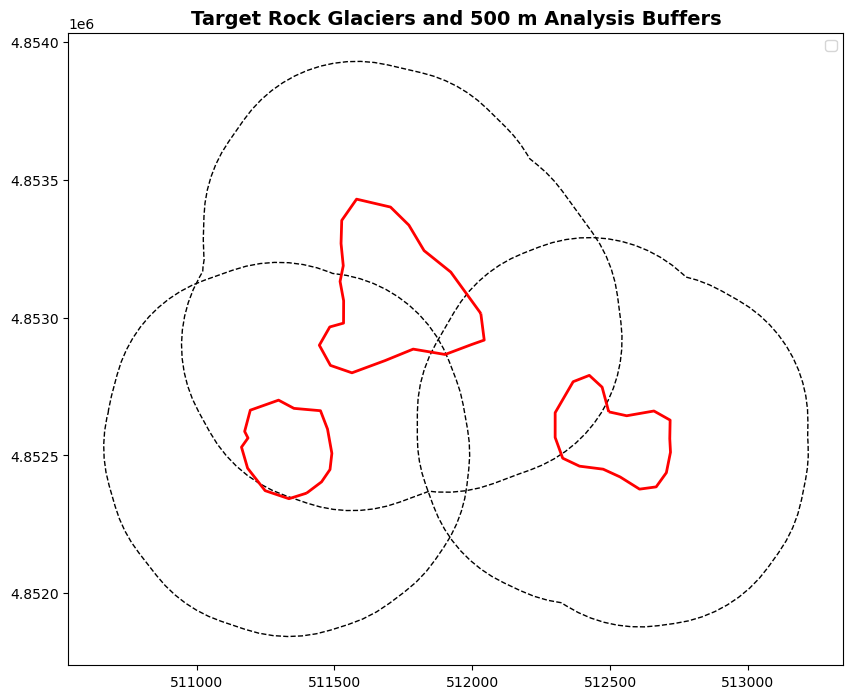

In [28]:
# Plot target glaciers and buffers
fig, ax = plt.subplots(figsize=(10, 10))

gdf_target.set_geometry('geometry_buffer').plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1,
    linestyle='--',
    label='300 m buffer'
)

gdf_target.set_geometry('geometry_original').plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    linewidth=2,
    label='Rock glacier'
)

ax.set_title(
    'Target Rock Glaciers and 500 m Analysis Buffers',
    fontsize=14,
    fontweight='bold'
)

ax.set_aspect('equal')
ax.legend()

plt.show()

## Corrected local normalized cross-correlation

For every reference chip, NCC searches for the most similar chip within the larger search window.

For each candidate position:

- the reference chip is zero-mean normalized;
- the candidate search chip is independently normalized;
- the correlation coefficient is calculated;
- the highest correlation is selected as the best match.

The displacement is then calculated from the location of the best-match chip center relative to the original reference-chip center.

This avoids treating the entire search window as one normalized image.

In [29]:
# NCC function 

def normalized_cross_correlation(template, search):
    """
    Calculate local normalized cross-correlation.

    Parameters
    ----------
    template : 2D numpy array
        Reference/template chip.

    search : 2D numpy array
        Larger search region.

    Returns
    -------
    ncc : 2D numpy array
        NCC value at every valid template position.
    """

    template = np.asarray(template, dtype=np.float32)
    search = np.asarray(search, dtype=np.float32)

    th, tw = template.shape
    sh, sw = search.shape

    if sh < th or sw < tw:
        return None

    # Require finite data.
    if not np.isfinite(template).all():
        return None

    if not np.isfinite(search).all():
        return None

    # Zero-mean reference template.
    template_zero = template - template.mean()

    template_norm = np.sqrt(
        np.sum(template_zero ** 2)
    )

    if template_norm < 1e-6:
        return None

    # Correlation numerator.
    numerator = correlate2d(
    search,
    template_zero,
    mode='valid'
    )   

    # Calculate mean and variance of each candidate search chip.
    kernel = np.ones(
        (th, tw),
        dtype=np.float32
    )

    n = th * tw

    local_sum = correlate2d(
        search,
        kernel,
        mode='valid'
    )

    local_sum_sq = correlate2d(
        search ** 2,
        kernel,
        mode='valid'
    )

    local_variance = (
        local_sum_sq
        - (local_sum ** 2) / n
    )

    local_variance = np.maximum(
        local_variance,
        0
    )

    denominator = (
        template_norm
        * np.sqrt(local_variance)
    )

    ncc = np.full(
        numerator.shape,
        np.nan,
        dtype=np.float32
    )

    valid = denominator > 1e-6

    ncc[valid] = (
        numerator[valid]
        / denominator[valid]
    )

    return ncc

In [30]:
# NCC tracking function 

def ncc_track(
    ref_img,
    search_img,
    search_chip=64,
    ref_chip=32,
    grid_spacing=8
):
    """
    NCC feature tracking.

    Returns
    -------
    list of tuples:
        row
        col
        dx_px
        dy_px
        corr
    """

    if search_chip < ref_chip:
        raise ValueError(
            'search_chip must be >= ref_chip'
        )

    if search_chip % 2 != 0:
        raise ValueError(
            'search_chip must be even'
        )

    if ref_chip % 2 != 0:
        raise ValueError(
            'ref_chip must be even'
        )

    rows, cols = ref_img.shape

    half_search = search_chip // 2
    half_ref = ref_chip // 2

    results = []

    # Only use centers where the complete search window fits.
    row_centers = range(
        half_search,
        rows - half_search,
        grid_spacing
    )

    col_centers = range(
        half_search,
        cols - half_search,
        grid_spacing
    )

    for r in row_centers:

        for c in col_centers:

            # Reference chip.
            ref_chip_data = ref_img[
                r - half_ref:r + half_ref,
                c - half_ref:c + half_ref
            ]

            # Search window.
            search_data = search_img[
                r - half_search:r + half_search,
                c - half_search:c + half_search
            ]

            if ref_chip_data.shape != (
                ref_chip,
                ref_chip
            ):
                continue

            if search_data.shape != (
                search_chip,
                search_chip
            ):
                continue

            if not np.isfinite(
                ref_chip_data
            ).all():
                continue

            if not np.isfinite(
                search_data
            ).all():
                continue

            # Calculate NCC surface.
            corr = normalized_cross_correlation(
                ref_chip_data,
                search_data
            )

            if corr is None:
                continue

            if not np.isfinite(corr).any():
                continue

            # Best correlation peak.
            peak_idx = np.unravel_index(
                np.nanargmax(corr),
                corr.shape
            )

            peak_val = corr[peak_idx]

            # -------------------------------------------------------
            # Convert peak position to displacement.
            #
            # The search window starts at:
            #
            #     r - half_search
            #     c - half_search
            #
            # A template centered at the same location as the
            # reference chip begins at:
            #
            #     half_search - half_ref
            #
            # Therefore this is the zero-displacement peak.
            # -------------------------------------------------------

            zero_idx = (
                half_search - half_ref,
                half_search - half_ref
            )

            dy_px = (
                peak_idx[0]
                - zero_idx[0]
            )

            dx_px = (
                peak_idx[1]
                - zero_idx[1]
            )

            results.append(
                (
                    r,
                    c,
                    dx_px,
                    dy_px,
                    float(peak_val)
                )
            )

    return results

In [31]:
# -------------------------------------------------------------------
# MATCH 2001 HILLSHADE TO EXACT 1983 HILLSHADE GRID
# -------------------------------------------------------------------

from rasterio.warp import reproject, Resampling

ref_hs_path = out_dir / '1983_hillshade_1983_2001_pair.tif'
search_hs_path = out_dir / '2001_hillshade_1983_2001_pair.tif'

matched_hs_path = out_dir / '2001_hillshade_matched_to_1983.tif'

with rasterio.open(ref_hs_path) as ref:
    ref_hs = ref.read(1)
    ref_profile = ref.profile.copy()
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_width = ref.width
    ref_height = ref.height

with rasterio.open(search_hs_path) as src:
    search_hs = src.read(1)

    search_hs_matched = np.empty(
        (ref_height, ref_width),
        dtype=np.float32
    )

    reproject(
        source=search_hs,
        destination=search_hs_matched,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.bilinear
    )

ref_profile.update(
    dtype='float32',
    count=1,
    nodata=0
)

with rasterio.open(matched_hs_path, 'w', **ref_profile) as dst:
    dst.write(search_hs_matched, 1)

print(f"Saved: {matched_hs_path}")

Saved: /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/2001_hillshade_matched_to_1983.tif


In [32]:
# -------------------------------------------------------------------
# VERIFY HILLSHADE GRID
# -------------------------------------------------------------------

ref_info = inspect_raster(ref_hs_path)
search_info = inspect_raster(matched_hs_path)

print("HILLSHADE AFTER ALIGNMENT")
print("=" * 70)

print(f"Reference: {ref_hs_path.name}")
print(f"Search:    {matched_hs_path.name}")

same_crs = ref_info['crs'] == search_info['crs']

same_res = np.allclose(
    ref_info['res'],
    search_info['res']
)

same_dimensions = (
    ref_info['width'],
    ref_info['height']
) == (
    search_info['width'],
    search_info['height']
)

same_transform = (
    ref_info['transform'] == search_info['transform']
)

ref_bounds = [
    ref_info['bounds'].left,
    ref_info['bounds'].bottom,
    ref_info['bounds'].right,
    ref_info['bounds'].top
]

search_bounds = [
    search_info['bounds'].left,
    search_info['bounds'].bottom,
    search_info['bounds'].right,
    search_info['bounds'].top
]

same_bounds = np.allclose(
    ref_bounds,
    search_bounds
)

print(f"  Same CRS:        {same_crs}")
print(f"  Same resolution: {same_res}")
print(f"  Same dimensions: {same_dimensions}")
print(f"  Same transform:  {same_transform}")
print(f"  Same bounds:     {same_bounds}")

HILLSHADE AFTER ALIGNMENT
Reference: 1983_hillshade_1983_2001_pair.tif
Search:    2001_hillshade_matched_to_1983.tif
  Same CRS:        True
  Same resolution: True
  Same dimensions: True
  Same transform:  True
  Same bounds:     True


In [33]:
# -------------------------------------------------------------------
# CLIP ALIGNED 1983 / 2001 HILLSHADE PAIR
# TO TARGET ROCK GLACIERS + 300 m BUFFER
# -------------------------------------------------------------------

import rasterio
from rasterio.mask import mask

# -------------------------------------------------------------------
# INPUT / OUTPUT PATHS
# -------------------------------------------------------------------

ref_path = out_dir / '1983_hillshade_ash_aligned.tif'
search_path = out_dir / '2001_hillshade_ash_aligned.tif'

ref_clip_path = out_dir / '1983_hillshade_ncc_target_area.tif'
search_clip_path = out_dir / '2001_hillshade_ncc_target_area.tif'

# -------------------------------------------------------------------
# CREATE BUFFERED TARGET GEOMETRY
# -------------------------------------------------------------------

# Re-select target rock glaciers.
# target_ids are GeoDataFrame index values, not an attribute field.
target_rg = gdf_rg.loc[target_ids].copy()

target_buffer = target_rg.geometry.buffer(BUFFER_M)

analysis_area = target_buffer.union_all()

shapes = [analysis_area.__geo_interface__]

print("Clipping area:")
print(f"  Target rock glaciers: {target_ids}")
print(f"  Buffer: {BUFFER_M} m")
print(f"  Bounds: {analysis_area.bounds}")
# -------------------------------------------------------------------
# CLIP 1983
# -------------------------------------------------------------------

with rasterio.open(ref_path) as src:

    ref_clip, ref_transform = mask(
        src,
        shapes,
        crop=True
    )

    ref_profile = src.profile.copy()

    ref_profile.update(
        height=ref_clip.shape[1],
        width=ref_clip.shape[2],
        transform=ref_transform
    )

    with rasterio.open(
        ref_clip_path,
        'w',
        **ref_profile
    ) as dst:
        dst.write(ref_clip)

# -------------------------------------------------------------------
# CLIP 2001 USING THE EXACT SAME WINDOW
# -------------------------------------------------------------------

with rasterio.open(ref_clip_path) as ref:

    ref_window = rasterio.windows.Window(
        col_off=0,
        row_off=0,
        width=ref.width,
        height=ref.height
    )

    ref_bounds = ref.bounds

with rasterio.open(search_path) as src:

    # Because the two original rasters have identical transforms,
    # the same spatial bounds correspond to the same pixel window.
    window = rasterio.windows.from_bounds(
        ref_bounds.left,
        ref_bounds.bottom,
        ref_bounds.right,
        ref_bounds.top,
        transform=src.transform
    )

    window = window.round_offsets().round_lengths()

    search_clip = src.read(
        1,
        window=window
    )

    search_transform = src.window_transform(window)

    search_profile = src.profile.copy()

    search_profile.update(
        height=search_clip.shape[0],
        width=search_clip.shape[1],
        transform=search_transform
    )

    with rasterio.open(
        search_clip_path,
        'w',
        **search_profile
    ) as dst:
        dst.write(search_clip, 1)

# -------------------------------------------------------------------
# VERIFY FINAL CLIPPED PAIR
# -------------------------------------------------------------------

with rasterio.open(ref_clip_path) as ref:
    ref_shape = ref.shape
    ref_transform = ref.transform
    ref_bounds = ref.bounds

with rasterio.open(search_clip_path) as search:
    search_shape = search.shape
    search_transform = search.transform
    search_bounds = search.bounds

same_dimensions = ref_shape == search_shape
same_transform = ref_transform == search_transform

same_bounds = (
    np.allclose(
        [ref_bounds.left, ref_bounds.bottom,
         ref_bounds.right, ref_bounds.top],
        [search_bounds.left, search_bounds.bottom,
         search_bounds.right, search_bounds.top]
    )
)

print("\nCLIPPED PAIR CHECK")
print("=" * 70)
print(f"1983 shape:       {ref_shape}")
print(f"2001 shape:       {search_shape}")
print(f"Same dimensions:  {same_dimensions}")
print(f"Same transform:   {same_transform}")
print(f"Same bounds:      {same_bounds}")

print("\nOutput files:")
print(f"  {ref_clip_path}")
print(f"  {search_clip_path}")

Clipping area:
  Target rock glaciers: [9500, 9497, 9496]
  Buffer: 500 m
  Bounds: (510662.7649549967, 4851842.778614412, 513218.7627139068, 4853929.2540207)

CLIPPED PAIR CHECK
1983 shape:       (597, 731)
2001 shape:       (597, 731)
Same dimensions:  True
Same transform:   True
Same bounds:      True

Output files:
  /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_hillshade_ncc_target_area.tif
  /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/2001_hillshade_ncc_target_area.tif


In [34]:
# -------------------------------------------------------------------
# NCC 1: LOAD EXACTLY THE VERIFIED RASTERS
# -------------------------------------------------------------------

images = {}

# image_paths = {
#     'ortho': {
#         'ref': out_dir / '1983_ortho_aligned.tif',
#         'search': out_dir / '2001_ortho_matched_to_1983.tif',
#     },
#     'hillshade': {
#         'ref': out_dir / '1983_hillshade_1983_2001_pair.tif',
#         'search': out_dir / '2001_hillshade_matched_to_1983.tif',
#     },
# }
image_paths = {
    'hillshade': {
        'ref': out_dir / '1983_hillshade_ncc_target_area.tif',
        'search': out_dir / '2001_hillshade_ncc_target_area.tif',
    },
}

for label, paths in image_paths.items():

    ref_path = paths['ref']
    search_path = paths['search']

    print(f'\nLoading {label}')
    print(f'  Reference: {ref_path.name}')
    print(f'  Search:    {search_path.name}')

    # Make absolutely sure these are the files we intend to use.
    if not ref_path.exists():
        raise FileNotFoundError(
            f'Reference raster not found:\n{ref_path}'
        )

    if not search_path.exists():
        raise FileNotFoundError(
            f'Search raster not found:\n{search_path}'
        )

    with rasterio.open(ref_path) as src:

        ref_img = src.read(1).astype(np.float32)

        transform = src.transform
        ref_crs = src.crs
        ref_nodata = src.nodata

    with rasterio.open(search_path) as src:

        search_img = src.read(1).astype(np.float32)

        search_nodata = src.nodata

    # Convert nodata to NaN.
    if ref_nodata is not None:
        ref_img[ref_img == ref_nodata] = np.nan

    if search_nodata is not None:
        search_img[search_img == search_nodata] = np.nan

    # Verify dimensions.
    if ref_img.shape != search_img.shape:
        raise ValueError(
            f'{label}: raster dimensions differ: '
            f'{ref_img.shape} vs {search_img.shape}'
        )

    images[label] = {
        'ref': ref_img,
        'search': search_img,
        'transform': transform,
        'crs': ref_crs,
    }

    print(
        f'  Loaded successfully: '
        f'{ref_img.shape[1]} × {ref_img.shape[0]} pixels'
    )


Loading hillshade
  Reference: 1983_hillshade_ncc_target_area.tif
  Search:    2001_hillshade_ncc_target_area.tif
  Loaded successfully: 731 × 597 pixels


## now run NCC 

In [35]:
# Run NCC 2
ncc_results = {}

for label, data in images.items():

    print('\n' + '=' * 70)
    print(f'RUNNING NCC: {label.upper()}')
    print('=' * 70)

    results = ncc_track(
        data['ref'],
        data['search'],
        search_chip=SEARCH_CHIP,
        ref_chip=REF_CHIP,
        grid_spacing=GRID_SPACING
    )

    print(
        f'Raw chip matches: {len(results):,}'
    )

    transform = data['transform']

    xres = abs(transform.a)
    yres = abs(transform.e)

    records = []

    for (
        r,
        c,
        dx_px,
        dy_px,
        corr
    ) in results:

        x, y = transform * (c, r)

        dx_m = dx_px * xres
        dy_m = dy_px * yres

        length_m = np.hypot(
            dx_m,
            dy_m
        )

        v_myr = (
            length_m
            / DT_YEARS
        )

        records.append({
            'geometry': Point(x, y),
            'row': r,
            'col': c,
            'dx_px': dx_px,
            'dy_px': dy_px,
            'dx_m': dx_m,
            'dy_m': dy_m,
            'length_m': length_m,
            'v_myr': v_myr,
            'corr': corr,
            'source': label,
        })

    gdf = gpd.GeoDataFrame(
        records,
        geometry='geometry',
        crs=data['crs']
    )

    # Initial quality/plausibility filter.
    gdf_filt = gdf[
        (gdf['corr'] >= MIN_CORR) &
        (gdf['v_myr'] >= MIN_V) &
        (gdf['v_myr'] <= MAX_V)
    ].copy()

    print(
        f'Filtered matches: {len(gdf_filt):,}'
    )

    print(
        f'Median velocity: '
        f'{gdf_filt["v_myr"].median():.3f} m/yr'
    )

    print(
        f'Median correlation: '
        f'{gdf_filt["corr"].median():.3f}'
    )

    ncc_results[label] = gdf_filt

    out_path = (
        out_dir
        / f'ncc_{label}_{REF_YEAR}_{SEARCH_YEAR}.shp'
    )

    gdf_filt.to_file(out_path)

    print(
        f'Saved: {out_path}'
    )


RUNNING NCC: HILLSHADE
Raw chip matches: 1,293
Filtered matches: 1,220
Median velocity: 0.275 m/yr
Median correlation: 0.677
Saved: /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/ncc_hillshade_1983_2001.shp


Target rock glaciers found: 3
Target indices: [9500, 9497, 9496]


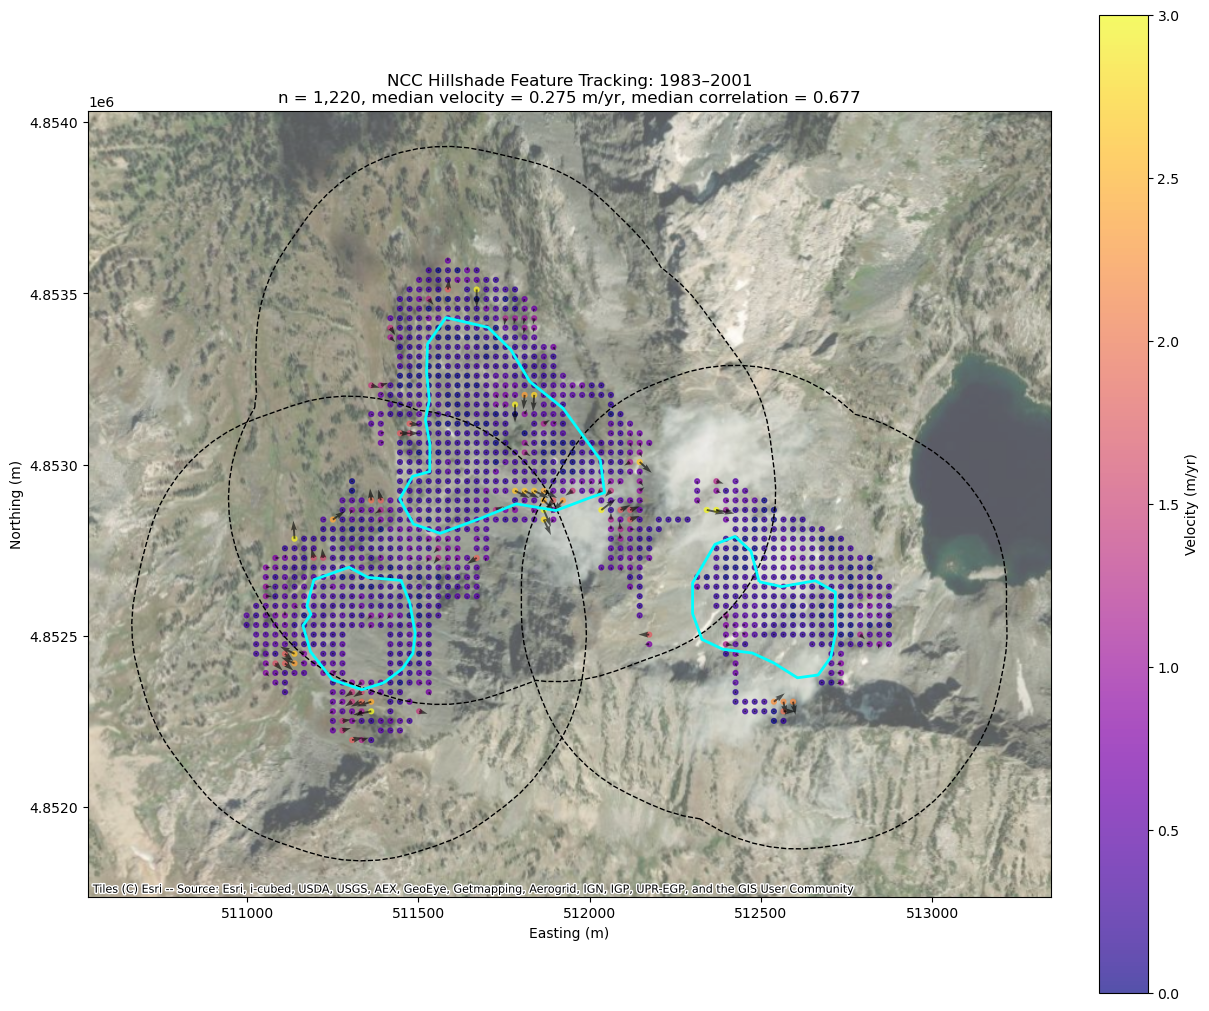

In [49]:
# -------------------------------------------------------------------
# NCC 3: PLOT HILLSHADE VELOCITY VECTORS
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import contextily as ctx

label = 'hillshade'
gdf = ncc_results[label].copy()

# Load rock glaciers
gdf_rg = gpd.read_file(
    '/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp'
).to_crs(CRS)

# Target rock glaciers are identified by their GeoDataFrame index
target_rg = gdf_rg.loc[target_ids].copy()

print(f"Target rock glaciers found: {len(target_rg)}")
print(f"Target indices: {target_rg.index.tolist()}")

# ---------------------------------------------------------------
# Create 300 m buffer
# ---------------------------------------------------------------

target_buffer = target_rg.geometry.buffer(BUFFER_M)

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 10),
    constrained_layout=True
)

# Velocity points
sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=gdf['v_myr'],
    cmap='plasma',
    s=12,
    alpha=0.7,
    vmin=0,
    vmax=3,
    zorder=3
)

# Displacement vectors
ax.quiver(
    gdf.geometry.x,
    gdf.geometry.y,
    gdf['dx_m'],
    gdf['dy_m'],
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.002,
    alpha=0.6,
    zorder=4
)

# Rock glacier outlines
target_rg.boundary.plot(
    ax=ax,
    color='cyan',
    linewidth=2,
    zorder=5
)

# 300 m buffer
target_buffer.boundary.plot(
    ax=ax,
    color='black',
    linewidth=1,
    linestyle='--',
    zorder=4
)

# Satellite basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    crs=CRS,
    alpha=0.65
)

cbar = plt.colorbar(
    sc,
    ax=ax,
    label='Velocity (m/yr)'
)

ax.set_title(
    f'NCC Hillshade Feature Tracking: {REF_YEAR}–{SEARCH_YEAR}\n'
    f'n = {len(gdf):,}, '
    f'median velocity = {gdf["v_myr"].median():.3f} m/yr, '
    f'median correlation = {gdf["corr"].median():.3f}'
)

ax.set_aspect('equal')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

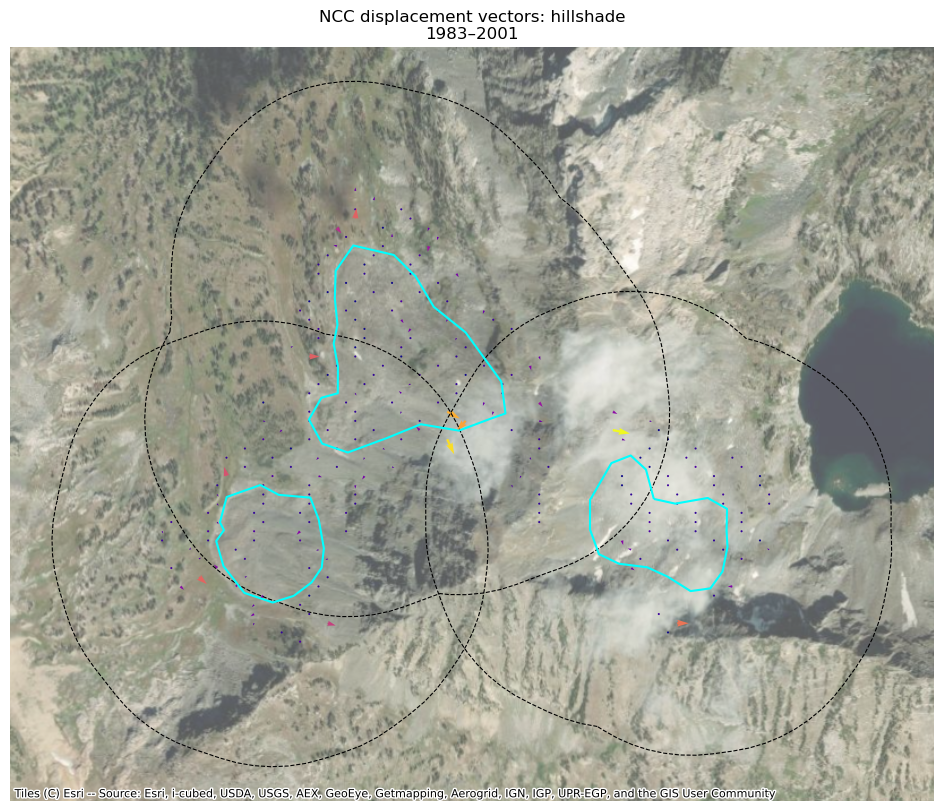

In [50]:
# -------------------------------------------------------------------
# NCC 4: DISPLACEMENT VECTORS
# -------------------------------------------------------------------

label = 'hillshade'
gdf = ncc_results[label]

# Plot every 5th vector for readability.
q = gdf.iloc[::5]

fig, ax = plt.subplots(
    figsize=(10, 8),
    constrained_layout=True
)

ax.quiver(
    q.geometry.x,
    q.geometry.y,
    q.dx_m,
    q.dy_m,
    q.v_myr,
    cmap='plasma',
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.0025,
    zorder=3
)

# Rock glacier outlines
target_rg.boundary.plot(
    ax=ax,
    color='cyan',
    linewidth=1.5,
    zorder=5
)

# 300 m buffer
target_buffer.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.8,
    linestyle='--',
    zorder=4
)

# Satellite basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    crs=CRS,
    alpha=0.65
)

ax.set_title(
    f'NCC displacement vectors: {label}\n'
    f'{REF_YEAR}–{SEARCH_YEAR}'
)

ax.set_aspect('equal')
ax.set_axis_off()

plt.show()

## Rock glacier vs. surrounding terrain

We classify each NCC vector into:

- **rock_glacier**: inside the original mapped rock-glacier polygon
- **buffer**: inside the 300 m buffer but outside the original polygon
- **outside_300m_buffer**: farther from the mapped rock glacier

This allows us to ask whether the apparent signal is spatially concentrated over the rock glacier rather than being a broad registration artifact.

In [38]:
# -------------------------------------------------------------------
# NCC 5: CLASSIFY VECTORS SPATIALLY
# -------------------------------------------------------------------

def classify_vectors(gdf):

    gdf = gdf.copy()

    # Original rock-glacier polygons
    original = target_rg[
        ['geometry']
    ].copy()

    # 300 m buffered polygons
    buffered = target_rg.copy()
    buffered['geometry'] = buffered.geometry.buffer(BUFFER_M)
    buffered = buffered[
        ['geometry']
    ].copy()

    # ---------------------------------------------------------------
    # Inside original rock glaciers
    # ---------------------------------------------------------------

    inside_rg = gpd.sjoin(
        gdf,
        original,
        how='left',
        predicate='within'
    )

    # ---------------------------------------------------------------
    # Inside 300 m buffer
    # ---------------------------------------------------------------

    inside_buffer = gpd.sjoin(
        gdf,
        buffered,
        how='left',
        predicate='within'
    )

    # Start everything outside the buffer
    gdf['region'] = 'outside_300m_buffer'

    # Buffer matches
    buffer_idx = inside_buffer.index[
        inside_buffer.index_right.notna()
    ]

    # Rock-glacier matches
    rg_idx = inside_rg.index[
        inside_rg.index_right.notna()
    ]

    gdf.loc[
        buffer_idx,
        'region'
    ] = 'buffer'

    # Rock glaciers take priority over buffer
    gdf.loc[
        rg_idx,
        'region'
    ] = 'rock_glacier'

    return gdf


classified = {}

for label, gdf in ncc_results.items():

    classified[label] = classify_vectors(gdf)

    print(
        f'\n{label.upper()}'
    )

    print(
        classified[label]
        .groupby('region')
        .v_myr
        .agg(
            ['count', 'median', 'mean', 'std']
        )
    )


HILLSHADE
              count    median      mean       std
region                                           
buffer          751  0.274986  0.447167  0.471726
rock_glacier    469  0.194444  0.309917  0.388324


uh oh... the rock glacier and surrounding terrain have essentially identical velocities. In fact off-glacier velocity is a tiny bit higher. Concerned that this indicates image-registration/correlation artifacts rather than actual rock-glacier motion...

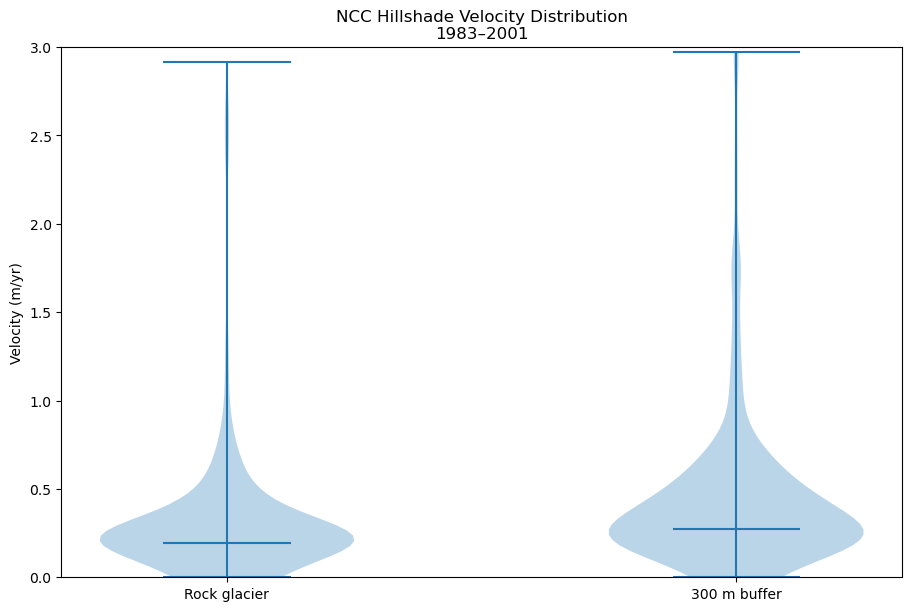

In [39]:
# -------------------------------------------------------------------
# NCC 6: VELOCITY DISTRIBUTIONS
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True
)

regions = [
    'rock_glacier',
    'buffer'
]

labels = [
    'Rock glacier',
    '300 m buffer'
]

gdf = classified['hillshade']

data = [
    gdf.loc[
        gdf['region'] == region,
        'v_myr'
    ].dropna()
    for region in regions
]

ax.violinplot(
    data,
    positions=np.arange(len(regions)),
    showmedians=True
)

ax.set_xticks(
    np.arange(len(regions))
)

ax.set_xticklabels(labels)

ax.set_ylabel(
    'Velocity (m/yr)'
)

ax.set_ylim(
    0,
    MAX_V
)

ax.set_title(
    f'NCC Hillshade Velocity Distribution\n'
    f'{REF_YEAR}–{SEARCH_YEAR}'
)

plt.show()

## Directional coherence

Magnitude alone is not enough.

A spatially uniform registration error could produce substantial apparent velocity everywhere. A physically plausible rock-glacier signal should generally show some directional organization.

For each region, we calculate:

**directional coherence = magnitude of mean displacement vector / mean displacement magnitude**

Values closer to 1 indicate that vectors tend to point in a common direction.

Values closer to 0 indicate that directions are more dispersed.

In [40]:
# -------------------------------------------------------------------
# NCC 7: DIRECTIONAL COHERENCE
# -------------------------------------------------------------------

def directional_metrics(df):

    if len(df) == 0:

        return {
            'n': 0,
            'median_v_myr': np.nan,
            'mean_v_myr': np.nan,
            'mean_dx_m': np.nan,
            'mean_dy_m': np.nan,
            'directional_coherence': np.nan,
        }

    mean_dx = df.dx_m.mean()
    mean_dy = df.dy_m.mean()

    mean_vector_length = np.hypot(
        mean_dx,
        mean_dy
    )

    mean_magnitude = np.mean(
        np.hypot(
            df.dx_m,
            df.dy_m
        )
    )

    if mean_magnitude > 0:

        coherence = (
            mean_vector_length
            / mean_magnitude
        )

    else:

        coherence = np.nan

    return {
        'n': len(df),
        'median_v_myr': df.v_myr.median(),
        'mean_v_myr': df.v_myr.mean(),
        'mean_dx_m': mean_dx,
        'mean_dy_m': mean_dy,
        'directional_coherence': coherence,
    }


rows = []

for source, gdf in classified.items():

    for region in regions:

        subset = gdf[
            gdf.region == region
        ]

        metrics = directional_metrics(
            subset
        )

        metrics['source'] = source
        metrics['region'] = region

        rows.append(metrics)


directional_summary = pd.DataFrame(
    rows
)

print(
    directional_summary.to_string(
        index=False
    )
)

  n  median_v_myr  mean_v_myr  mean_dx_m  mean_dy_m  directional_coherence    source       region
469      0.194444    0.309917   0.059701  -3.298507               0.591386 hillshade rock_glacier
751      0.274986    0.447167   1.202397  -2.339547               0.326803 hillshade       buffer


Above results suggest the NCC vectors over the rock glacier have substantially more consistent direction than the surrounding terrain! so that's encouraging

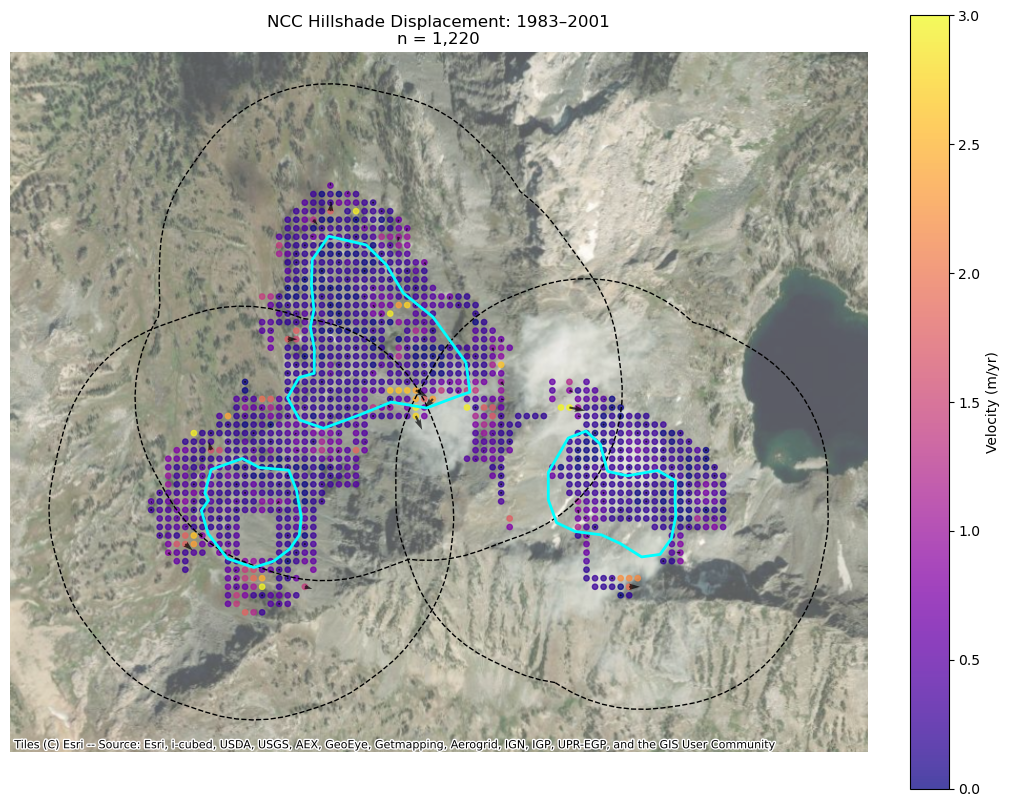

In [51]:
# -------------------------------------------------------------------
# NCC 8: VELOCITY MAGNITUDE + DIRECTION MAP
# -------------------------------------------------------------------

label = 'hillshade'
gdf = classified[label]

fig, ax = plt.subplots(
    figsize=(10, 8),
    constrained_layout=True
)

# Plot velocity magnitude
sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=gdf['v_myr'],
    cmap='plasma',
    s=15,
    alpha=0.75,
    vmin=0,
    vmax=MAX_V,
    zorder=3
)

# Plot every 5th vector for readability
q = gdf.iloc[::5]

ax.quiver(
    q.geometry.x,
    q.geometry.y,
    q['dx_m'],
    q['dy_m'],
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.0025,
    alpha=0.7,
    zorder=4
)

# Rock glacier outlines
target_rg.boundary.plot(
    ax=ax,
    color='cyan',
    linewidth=2,
    zorder=5
)

# 300 m buffer
target_buffer.boundary.plot(
    ax=ax,
    color='black',
    linewidth=1,
    linestyle='--',
    zorder=4
)

# Satellite basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    crs=CRS,
    alpha=0.65
)

plt.colorbar(
    sc,
    ax=ax,
    label='Velocity (m/yr)'
)

ax.set_title(
    f'NCC Hillshade Displacement: '
    f'{REF_YEAR}–{SEARCH_YEAR}\n'
    f'n = {len(gdf):,}'
)

ax.set_aspect('equal')
ax.set_axis_off()

plt.show()

## Check whether vectors are hitting the search-window limit

This is an important artifact diagnostic.

With a 64 × 64 search window and 32 × 32 reference chip, the maximum possible displacement is approximately:

**±16 pixels**

in either direction.

If a large fraction of vectors occur near that limit, the tracking result may be constrained by the search window rather than representing real displacement.

In [42]:
# Check displacement limits

max_expected_px = (
    SEARCH_CHIP - REF_CHIP
) / 2

print(
    f'Maximum displacement represented by '
    f'the search geometry: ±{max_expected_px:.0f} pixels'
)

for source, gdf in ncc_results.items():

    near_limit = (
        (gdf.dx_px.abs() >= max_expected_px - 1) |
        (gdf.dy_px.abs() >= max_expected_px - 1)
    )

    fraction = near_limit.mean()

    print(
        f'{source}: '
        f'{near_limit.sum():,} / {len(gdf):,} '
        f'({fraction * 100:.2f}%) near search limit'
    )

Maximum displacement represented by the search geometry: ±16 pixels
hillshade: 6 / 1,220 (0.49%) near search limit


## Ortho vs. hillshade

The ortho and hillshade results are not expected to be identical.

They contain different image texture and therefore different trackable features.

The useful question is whether both produce **broadly coherent and physically plausible patterns**, particularly over the same rock-glacier morphology.

In [43]:
# # Compare velocity distributions

# image_paths = {
#     'hillshade': {
#         'ref': out_dir / '1983_hillshade_ncc_target_area.tif',
#         'search': out_dir / '2001_hillshade_ncc_target_area.tif',
#     },
# }
# fig, ax = plt.subplots(
#     figsize=(8, 6)
# )

# data = [
#     classified['ortho']['v_myr'].dropna(),
#     classified['hillshade']['v_myr'].dropna()
# ]

# ax.violinplot(
#     data,
#     positions=[0, 1],
#     showmedians=True
# )

# ax.set_xticks(
#     [0, 1]
# )

# ax.set_xticklabels(
#     ['Ortho', 'Hillshade']
# )

# ax.set_ylabel(
#     'Velocity (m/yr)'
# )

# ax.set_ylim(
#     0,
#     MAX_V
# )

# ax.set_title(
#     f'NCC {REF_YEAR} → {SEARCH_YEAR}'
# )

# plt.show()

In [44]:
# load IMCORR
# Existing IMCORR result from your previous analysis.

imcorr_path = (
    out_dir
    / 'velocityvectors_aug27'
    / 'OneDrive_1_8-27-2026'
    / '1983to2001imcorr'
    / 'aug27_1983to2001_hillshade_target_rg_DISP_VEC.shp'
)

if imcorr_path.exists():

    imcorr = gpd.read_file(
        imcorr_path
    ).to_crs(CRS)

    imcorr['v_myr'] = (
        imcorr['DISP_REAL']
        / DT_YEARS
    )

    # Same filtering you used in your previous IMCORR analysis.
    imcorr = imcorr[
        (imcorr['STRENGTH'] >= 5.0) &
        (imcorr['v_myr'] >= 0.05) &
        (imcorr['v_myr'] <= 3.0) &
        (imcorr['FLAG'] == 1)
    ].copy()

    print(
        f'IMCORR vectors: {len(imcorr):,}'
    )

    print(
        f'IMCORR median velocity: '
        f'{imcorr.v_myr.median():.3f} m/yr'
    )

else:

    imcorr = None

    print(
        'IMCORR result not found at:'
    )

    print(imcorr_path)

/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


IMCORR vectors: 11,272
IMCORR median velocity: 0.635 m/yr


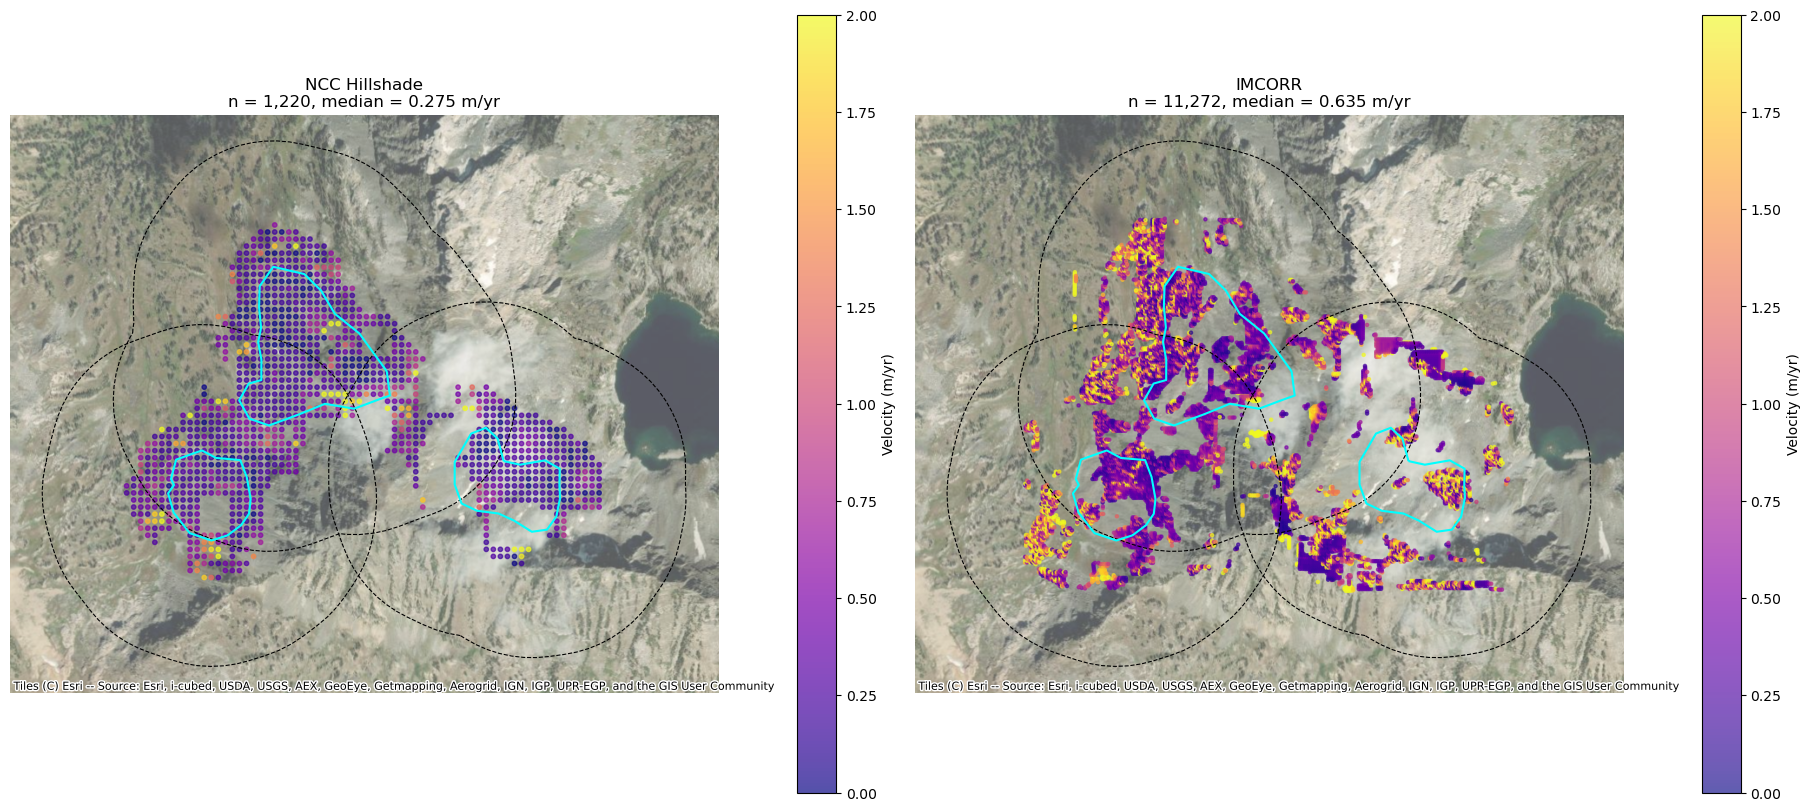

In [52]:
# -------------------------------------------------------------------
# NCC vs IMCORR: VELOCITY COMPARISON MAP
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import contextily as ctx

# ---------------------------------------------------------------
# NCC
# ---------------------------------------------------------------

ncc = classified['hillshade'].copy()

# ---------------------------------------------------------------
# IMCORR
# ---------------------------------------------------------------

# Use the existing IMCORR GeoDataFrame
# IMCORR geometries are LineStrings, so calculate their centroids
imcorr_plot = imcorr.copy()

imcorr_plot['plot_geometry'] = (
    imcorr_plot.geometry.centroid
)

# Create a temporary GeoDataFrame using the centroid geometry
imcorr_points = gpd.GeoDataFrame(
    imcorr_plot.drop(
        columns='geometry'
    ),
    geometry='plot_geometry',
    crs=imcorr.crs
)

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    constrained_layout=True
)

# ===============================================================
# NCC
# ===============================================================

sc1 = axes[0].scatter(
    ncc.geometry.x,
    ncc.geometry.y,
    c=ncc['v_myr'],
    cmap='plasma',
    s=10,
    alpha=0.7,
    vmin=0,
    vmax=2,
    zorder=3
)

target_rg.boundary.plot(
    ax=axes[0],
    color='cyan',
    linewidth=1.5,
    zorder=5
)

target_buffer.boundary.plot(
    ax=axes[0],
    color='black',
    linewidth=0.8,
    linestyle='--',
    zorder=4
)

# Satellite basemap
ctx.add_basemap(
    axes[0],
    source=ctx.providers.Esri.WorldImagery,
    crs=CRS,
    alpha=0.65
)

axes[0].set_title(
    f'NCC Hillshade\n'
    f'n = {len(ncc):,}, '
    f'median = {ncc["v_myr"].median():.3f} m/yr'
)

axes[0].set_aspect('equal')
axes[0].set_axis_off()

plt.colorbar(
    sc1,
    ax=axes[0],
    label='Velocity (m/yr)'
)

# ===============================================================
# IMCORR
# ===============================================================

sc2 = axes[1].scatter(
    imcorr_points.geometry.x,
    imcorr_points.geometry.y,
    c=imcorr_points['v_myr'],
    cmap='plasma',
    s=5,
    alpha=0.65,
    vmin=0,
    vmax=2,
    zorder=3
)

target_rg.boundary.plot(
    ax=axes[1],
    color='cyan',
    linewidth=1.5,
    zorder=5
)

target_buffer.boundary.plot(
    ax=axes[1],
    color='black',
    linewidth=0.8,
    linestyle='--',
    zorder=4
)

# Satellite basemap
ctx.add_basemap(
    axes[1],
    source=ctx.providers.Esri.WorldImagery,
    crs=CRS,
    alpha=0.65
)

axes[1].set_title(
    f'IMCORR\n'
    f'n = {len(imcorr_points):,}, '
    f'median = {imcorr_points["v_myr"].median():.3f} m/yr'
)

axes[1].set_aspect('equal')
axes[1].set_axis_off()

plt.colorbar(
    sc2,
    ax=axes[1],
    label='Velocity (m/yr)'
)

plt.show()

## Method comparison

This comparison is descriptive.

We are **not** assuming that either NCC or IMCORR is correct.

Instead, we ask whether the two approaches show:

- similar spatial organization,
- similar distinction between rock-glacier and surrounding terrain,
- similar directional behavior,
- and physically plausible velocity magnitudes.

Substantial disagreement is itself a useful result because it identifies uncertainty in historical feature tracking.

In [46]:
# Summary stats

comparison_rows = []

for source, gdf in classified.items():

    for region in regions:

        subset = gdf[
            gdf['region'] == region
        ]

        comparison_rows.append({
            'method': f'NCC_{source}',
            'region': region,
            'n': len(subset),
            'median_v_myr': (
                subset['v_myr'].median()
                if len(subset)
                else np.nan
            ),
            'mean_v_myr': (
                subset['v_myr'].mean()
                if len(subset)
                else np.nan
            ),
            'median_corr': (
                subset['corr'].median()
                if len(subset)
                else np.nan
            ),
        })


if imcorr is not None:

    # Classify IMCORR spatially using the same target
    # rock-glacier polygons and 300 m buffer.
    imcorr_classified = classify_vectors(
        imcorr
    )

    for region in regions:

        subset = imcorr_classified[
            imcorr_classified['region'] == region
        ]

        comparison_rows.append({
            'method': 'IMCORR',
            'region': region,
            'n': len(subset),
            'median_v_myr': (
                subset['v_myr'].median()
                if len(subset)
                else np.nan
            ),
            'mean_v_myr': (
                subset['v_myr'].mean()
                if len(subset)
                else np.nan
            ),
            'median_corr': np.nan,
        })


comparison_summary = pd.DataFrame(
    comparison_rows
)

print(
    comparison_summary.to_string(
        index=False
    )
)

       method       region    n  median_v_myr  mean_v_myr  median_corr
NCC_hillshade rock_glacier  469      0.194444    0.309917     0.731678
NCC_hillshade       buffer  751      0.274986    0.447167     0.630240
       IMCORR rock_glacier 3184      0.495743    0.707861          NaN
       IMCORR       buffer 8088      0.708186    0.936981          NaN


In [47]:
# # Save directional-coherence diagnostics.

# directional_path = (
#     out_dir
#     / f'ncc_{REF_YEAR}_{SEARCH_YEAR}_directional_coherence.csv'
# )

# directional_summary.to_csv(
#     directional_path,
#     index=False
# )

# print(
#     f'Saved:\n{directional_path}'
# )


# # Save method-comparison summary.

# comparison_path = (
#     out_dir
#     / f'ncc_{REF_YEAR}_{SEARCH_YEAR}_method_comparison.csv'
# )

# comparison_summary.to_csv(
#     comparison_path,
#     index=False
# )

# print(
#     f'Saved:\n{comparison_path}'
# )

In [48]:
# for source, gdf in ncc_results.items():

#     output_path = (
#         out_dir
#         / f'ncc_{source}_{REF_YEAR}_{SEARCH_YEAR}.shp'
#     )

#     gdf.to_file(
#         output_path
#     )

#     print(
#         f'Saved: {output_path.name}'
#     )

# Interpretation checklist

## Evidence supporting a plausible historical NCC signal

Look for:

- Spatially coherent displacement patches.
- Coherence that follows recognizable rock-glacier morphology.
- Directionally organized vectors over individual rock glaciers.
- Lower or less organized displacement on surrounding stable terrain.
- Similar broad behavior between ortho and hillshade tracking.
- Velocities within a physically plausible range for rock glaciers.
- Little evidence that vectors are constrained by the search-window boundary.
- High-quality correlations concentrated in the coherent signal.

## Evidence suggesting registration error or tracking artifacts

Look for:

- Similar displacement magnitude and direction on and off rock glaciers.
- One dominant displacement direction across the entire scene.
- Strong apparent motion along image boundaries.
- Large numbers of vectors at the search-window limit.
- Large changes in the apparent signal after modest changes in correlation threshold.
- Very different spatial patterns between ortho and hillshade.
- High correlation without a coherent spatial pattern.
- Apparent motion in clearly stable terrain.

## Interpretation of the IMCORR comparison

Do not ask:

> "Does NCC reproduce IMCORR?"

Instead ask:

> "Do NCC and IMCORR independently produce spatially coherent and physically plausible signals, and where do they agree or disagree?"

Agreement between independent methods strengthens confidence.

Disagreement identifies uncertainty that should be investigated rather than automatically assigning one method as correct.

## Core hypothesis

The working hypothesis is:

**NCC feature tracking can recover spatially coherent and physically plausible historical rock-glacier surface velocities from pre-SAR optical imagery, with displacement patterns distinguishable from registration noise on surrounding stable terrain.**

Shape: (228, 2)

CRS:
EPSG:5070

Columns:
['FID', 'geometry']

First 5 rows:


,FID,geometry
0,0,"POLYGON ((-1988501.529 1716965.353, -1988890.6..."
1,1,"POLYGON ((-1999177.643 1868743.908, -1999206.0..."
2,2,"POLYGON ((-1995252.489 1950512.014, -1995651.3..."
3,3,"POLYGON ((-2033705.866 1971776.225, -2034137.2..."
4,4,"POLYGON ((-2034584.722 2008984.017, -2034965.5..."



Geometry types:
Polygon    228
Name: count, dtype: int64

Geometry validity:
True    228
Name: count, dtype: int64

Bounds:
[-2175290.24067467  1205954.89490153  -770130.26949748  3140412.67937438]


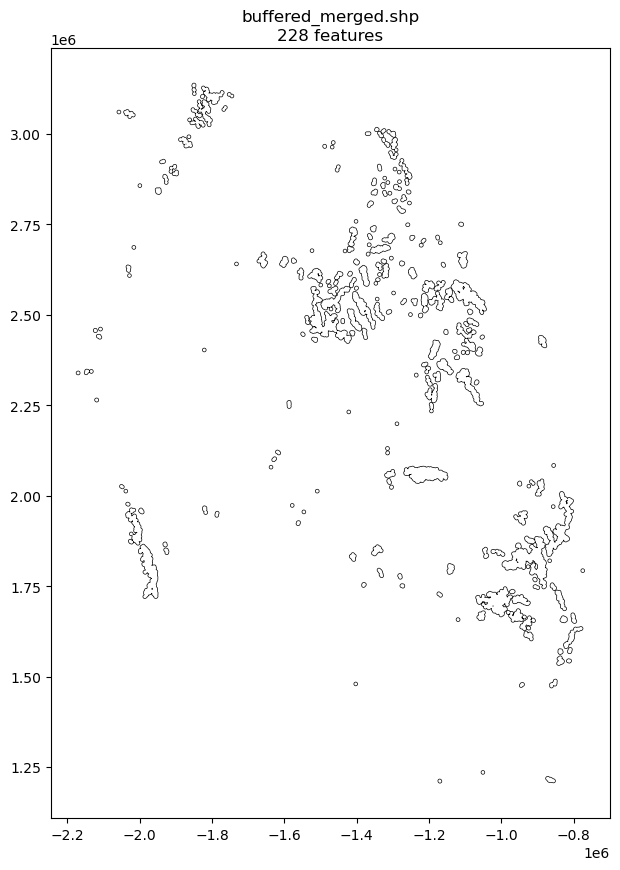

In [53]:
# -------------------------------------------------------------------
# EXAMINE CO-AUTHOR'S BUFFERED MERGED SHAPEFILE
# -------------------------------------------------------------------

import geopandas as gpd
import matplotlib.pyplot as plt

SHAPEFILE = (
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/'
    'glaciers_buffered_merged/buffered_merged.shp'
)

# Load shapefile
gdf = gpd.read_file(SHAPEFILE)

# Basic information
print('Shape:', gdf.shape)
print('\nCRS:')
print(gdf.crs)

print('\nColumns:')
print(gdf.columns.tolist())

print('\nFirst 5 rows:')
display(gdf.head())

print('\nGeometry types:')
print(gdf.geometry.geom_type.value_counts())

print('\nGeometry validity:')
print(gdf.geometry.is_valid.value_counts())

print('\nBounds:')
print(gdf.total_bounds)

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=0.5
)

ax.set_title(
    f'buffered_merged.shp\n'
    f'{len(gdf):,} features'
)

ax.set_aspect('equal')
plt.show()